In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal, init_to_median
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import gc
import os


# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from utils.data_generator import DataGenerator
from utils.methods_2 import evaluate_metrics
from utils.recursive_inference import recursive_inference
from utils.zoomed_plots import zoomed_plots

In [9]:
from scipy.signal import savgol_filter

In [10]:
mat_file = sio.loadmat('./real_data/100307.REST1.LR.SchaeferS.ptseries.mat')
data = torch.from_numpy(mat_file['tseries']).float()

In [11]:
data.shape

torch.Size([119, 1200])

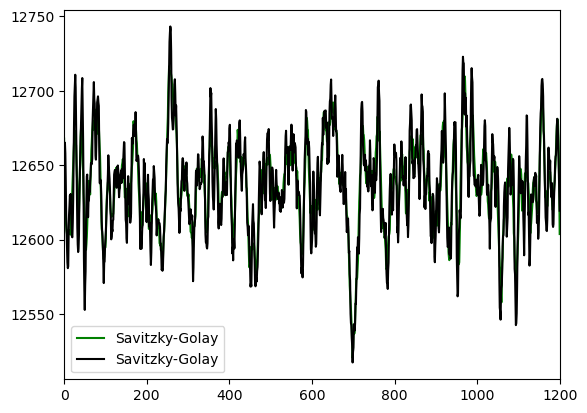

In [57]:
smoothed = savgol_filter(data, window_length=21, polyorder=3)
#plt.plot(range(data.shape[1]), data[0,:], label='Noisy Signal')
plt.plot(range(data.shape[1]), smoothed[0,:], label='Savitzky-Golay', color='green')
smoothed11 = savgol_filter(data, window_length=11, polyorder=3)
plt.plot(range(data.shape[1]), smoothed11[0,:], label='Savitzky-Golay', color='black')
plt.xlim(0,1200)
plt.legend()
plt.show()

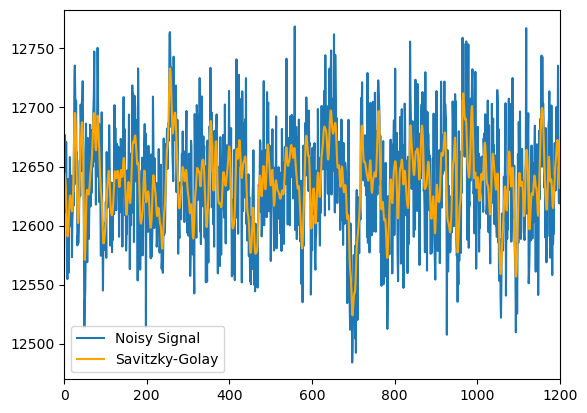

In [44]:
from scipy.ndimage import gaussian_filter1d

smoothed = gaussian_filter1d(data, sigma=2)
plt.plot(range(data.shape[1]), data[0,:], label='Noisy Signal')
plt.plot(range(data.shape[1]), smoothed[0,:], label='Savitzky-Golay', color='orange')
plt.xlim(0,1200)
plt.legend()
plt.show()